## Revenue identity: R = B × OPB × AOV

For country `c`, year `t`:

$$
R_{ct} = B_{ct} \times \text{OPB}_{ct} \times \text{AOV}_{ct}
$$

- **B** = buyers, **OPB** = orders per buyer, **AOV** = average order value, **R** = revenue
- Holds by definition — a standard multiplicative accounting identity, not an assumption.

**Log form** (turns the product into a sum):

$$
\log R_{ct} = \log B_{ct} + \log \text{OPB}_{ct} + \log \text{AOV}_{ct}
$$

Useful for Bayesian modeling: each log-component can be modeled as its own
hierarchical Normal variable, summed to get `log R`, then exponentiated to
recover revenue (guaranteeing it stays positive).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm  # this is for NUTS
import arviz as az # diagnostics: R-hat, divergence, az.summary()

g++ not available, if using conda: `conda install gxx`


##  Case Study Q1 : three steps to a prior, then the data

**Market chosen:** Moldova

**Why:** Small e-commerce market with very limited direct data — a realistic
"data-poor" case where the hierarchical model needs to lean on structure
(covariate bridge + peer group) rather than its own observations.

**Peer group (similar GDP per capita, transition economies):**
- Albania
- Georgia
- Armenia

1. **Covariate bridge:** learn how OPB depends on GDP from countries with known OPB, then predict Moldova's OPB from its GDP.
2. **Peer adjustment:** shift that prediction by how far Moldova's peers sit from the bridge.
3. **Moldova's own data:** combine the prior with Moldova's observations (Bayes update) to get the posterior.

Everything is on the **log scale**: OPB must stay positive, and the revenue identity is multiplicative (log R = log B + log OPB + log AOV).


In [2]:
# Countries with known OPB (toy values) and their GDP per capita (USD)
known_countries = ["Ukraine", "Albania", "Georgia", "Armenia", "Serbia", "Bulgaria", "Romania"]
known_gdp = np.array([5000, 6878, 6877, 8556, 9500, 14000, 17000])
known_opb = np.array([1.6, 1.8, 2.1, 1.9, 2.4, 2.9, 3.2])

# Moldova's peer group, and their positions in the arrays above
peers = ["Albania", "Georgia", "Armenia"]
peer_idx = [known_countries.index(c) for c in peers]

# Moldova: GDP is known, OPB is almost unknown (one weak observation)
moldova_gdp = 6732
moldova_obs = np.log(np.array([2.4]))   # log scale
obs_noise_sd = 0.3                      # noise of one observation (log scale, ~30%)


**Precision** = how much we trust a source of information = 1 / variance.

$$
\tau_{\text{prior}} = \frac{1}{\sigma_{\text{prior}}^2}
$$

$$
\tau_{\text{obs}} = \frac{n}{\sigma_{\text{obs}}^2}
$$

- $\sigma_{\text{prior}}$ = uncertainty of the prior (small → high trust)
- $\sigma_{\text{obs}}$ = noise of a single observation (small → high trust)
- $n$ = number of observations (each one adds $1/\sigma_{\text{obs}}^2$ of trust, so more data → higher trust)


In [3]:
def bayesian_update_with_normal_prior(prior_mean, prior_sd, observations, obs_noise_sd):
    # prior_mean, prior_sd  = my belief before seeing any data (prior)
    # observations          = the data I actually observed
    # obs_noise_sd          = how noisy / unreliable each observation is


    prior_precision = 1 / prior_sd**2           # how much I trust the prior (small sd = high trust)
    obs_precision = len(observations) / obs_noise_sd**2  # how much I trust the data (more data = high trust)

    post_precision = prior_precision + obs_precision    # total trust = sum of both

    obs_mean = observations.mean()
    post_mean = (prior_mean*prior_precision + obs_mean*obs_precision) / post_precision
    # ^ weighted average: whichever I trust more dominates the result

    #post_mean = (prior_mean*prior_precision + observations.sum()/obs_noise_sd**2) / post_precision
    # ^ ağırlıklı ortalama: hangisine daha çok güveniyorsam, o daha baskın çıkıyor

    post_sd = np.sqrt(1 / post_precision)   # more trust -> less uncertainty (smaller sd)
    return post_mean, post_sd

### Why `observations.sum() / obs_noise_sd**2` is the same as `obs_mean * obs_precision`

The posterior mean is a **precision-weighted average** (like a grade average weighted by credits):

$$
\mu_{\text{post}} = \frac{\tau_{\text{prior}}\,\mu_{\text{prior}} + \tau_{\text{obs}}\,\bar{y}}{\tau_{\text{prior}} + \tau_{\text{obs}}}
$$

- $\bar{y}$ = mean of the observations (`obs_mean`)
- $\tau_{\text{obs}} = n / \sigma^2$ = precision of the data (`obs_precision`)

In the code, the data term is written as `observations.sum() / obs_noise_sd**2`. This is the same thing, because the sum equals $n$ times the mean, and $n$ cancels out:

$$
\bar{y}\cdot\tau_{\text{obs}}
= \frac{\sum_i y_i}{n}\cdot\frac{n}{\sigma^2}
= \frac{\sum_i y_i}{\sigma^2}
$$

**Small check:** `observations = [2, 4, 6]`, `noise = 2`
- Short form: `sum / noise² = 12 / 4 = 3`
- Long form: `obs_mean * obs_precision = 4 * (3/4) = 3`

Both give the same result. The long form is easier to read, the short form is just the simplified version.


In [4]:
# Step 1: covariate bridge (GDP -> OPB), learned from countries with known OPB

# Work on the log scale: x = log(GDP), y = log(OPB)
log_gdp = np.log(known_gdp)
log_opb = np.log(known_opb)

# Slope: how much log(OPB) moves when log(GDP) moves (co-movement / spread of x)
slope = np.sum((log_gdp - log_gdp.mean()) * (log_opb - log_opb.mean())) / np.sum((log_gdp - log_gdp.mean())**2)

# Intercept: forces the line to pass through the average point (mean x, mean y)
intercept = log_opb.mean() - slope * log_gdp.mean()

def bridge_line(gdp):
    # Bridge prediction of log(OPB) for a given GDP
    return intercept + slope * np.log(gdp)

resid = log_opb - bridge_line(known_gdp)  # Each country's distance from the line = what GDP alone cannot explain

bridge_mean = bridge_line(moldova_gdp)
bridge_sd = resid.std(ddof=2)   # spread around the line (ddof=2: we fitted 2 parameters)

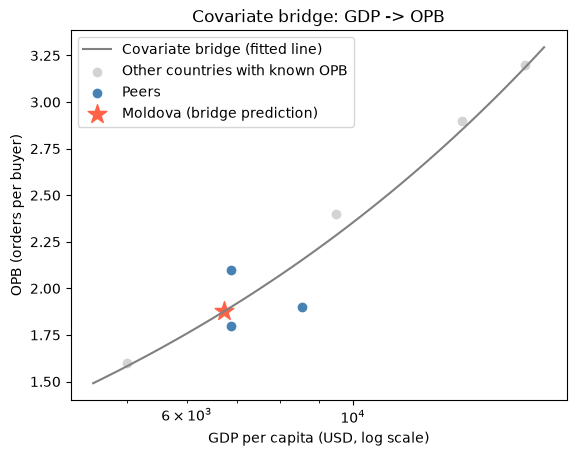

In [5]:
# The bridge: a fitted line through countries with known OPB
gdp_grid = np.linspace(4500, 18000, 100)
plt.plot(gdp_grid, np.exp(bridge_line(gdp_grid)), #np.exp(bridge_line(gdp_grid)) = np.exp(intercept + slope * np.log(gdp_grid))
         color="gray", label="Covariate bridge (fitted line)")

# Countries with known OPB: peers in blue, the rest in gray
is_peer = np.isin(known_countries, peers)
plt.scatter(known_gdp[~is_peer], known_opb[~is_peer], color="lightgray", label="Other countries with known OPB")
plt.scatter(known_gdp[is_peer], known_opb[is_peer], color="steelblue", label="Peers")

# Moldova: its GDP is known, its OPB comes from the line
plt.scatter(moldova_gdp, np.exp(bridge_mean), color="tomato", marker="*", s=200, label="Moldova (bridge prediction)")

plt.xscale("log")
plt.xlabel("GDP per capita (USD, log scale)")
plt.ylabel("OPB (orders per buyer)")
plt.title("Covariate bridge: GDP -> OPB")
plt.legend()
plt.show()


In [6]:
# Step 2: peer adjustment

# How far do Moldova's peers sit from the line?
peer_resid = resid[peer_idx]

# Shift the bridge prediction by the average peer deviation
peer_mean = bridge_mean + peer_resid.mean()
peer_sd = peer_resid.std(ddof=1)   # spread among the peers

In [7]:
# Step 3: update each prior with Moldova's own data, and compare

def opb_summary(mean, sd):
    # log scale -> OPB scale, shown as "value [95% interval]"
    return f"{np.exp(mean):.2f} [{np.exp(mean - 1.96*sd):.2f}, {np.exp(mean + 1.96*sd):.2f}]"

# Naive baseline: plain average of the peers' OPB, no GDP bridge
peer_log_opb = log_opb[peer_idx]

priors = {
    "Peer average (naive)": (peer_log_opb.mean(), peer_log_opb.std(ddof=1)),
    "Bridge only":          (bridge_mean, bridge_sd),
    "Bridge + peers":       (peer_mean, peer_sd),
}

# Update each prior with Moldova's observation
posteriors = {name: bayesian_update_with_normal_prior(mean, sd, moldova_obs, obs_noise_sd)
              for name, (mean, sd) in priors.items()}

print(f"{'':22s}{'prior':20s}posterior")
for name in priors:
    print(f"{name:22s}{opb_summary(*priors[name]):20s}{opb_summary(*posteriors[name])}")

# The main result (bridge + peers) is kept for later cells
scarce_mean, scarce_sd = posteriors["Bridge + peers"]


                      prior               posterior
Peer average (naive)  1.93 [1.66, 2.25]   1.96 [1.69, 2.27]
Bridge only           1.88 [1.61, 2.19]   1.91 [1.64, 2.22]
Bridge + peers        1.83 [1.46, 2.29]   1.89 [1.53, 2.34]


**Observation:** with one weak observation (2.4), the posterior (~1.89) stays close to the prior (~1.83): one noisy point cannot outweigh a prior built from the bridge and the peers.

**Revenue = Buyers × OPB × AOV**

In [8]:
# Rich data: 100 simulated observations of Moldova's OPB (true value 2.4), log scale
rich_obs = np.random.default_rng(0).normal(np.log(2.4), obs_noise_sd, size=100)
rich_mean, rich_sd = bayesian_update_with_normal_prior(peer_mean, peer_sd, rich_obs, obs_noise_sd)

print(f"Scarce data (1 obs):  {opb_summary(scarce_mean, scarce_sd)}")
print(f"Rich data (100 obs):  {opb_summary(rich_mean, rich_sd)}")


Scarce data (1 obs):  1.89 [1.53, 2.34]
Rich data (100 obs):  2.41 [2.28, 2.55]


## Takeaway

- With scarce data, Moldova's posterior leans heavily on the peer group
  (Albania, Georgia, Armenia) via the covariate bridge — this is
  **partial pooling** in action.
- With rich data, the posterior shifts to Moldova's own observations and
  becomes far more confident (lower `sd`).
- The same recipe (bridge, peer adjustment, own data) applies to **Buyers and AOV** too (e.g. population and internet use for Buyers, price level for AOV). Applied jointly across all markets, this is what the full hierarchical model does automatically: it learns how much each market should lean on its peers vs. its own evidence. Here only OPB is worked through.
- **Toy simplifications:** 7 countries, fixed noise, spread estimated from 3 peers. The full model learns these from all markets jointly.


# Case Study Q2: A new data source arrives

A new source gives observed OPB for 20 countries (2022–2024), of varying quality, including Moldova's peers.

- **Where it enters:** as likelihood data for each country's latent OPB. The peers now have real observations instead of assumptions.
- **What changes for OPB:** the peer offset is recomputed from the data-backed peer estimates, weighted by data quality (noisy peers count less). Moldova gets no new data, but its prior moves.
- **What changes for revenue:** only the log OPB term of log R = log B + log OPB + log AOV shifts. B and AOV stay the same.
- **Simplification:** here only the peers are simulated and the bridge stays fixed. In the full model all 20 countries also refit the bridge itself, and source quality is learned rather than assumed.


In [9]:
random_number_generator = np.random.default_rng(1)

# True OPB per peer (unknown in reality, only used to simulate the new data)
true_opb = {"Albania": 1.85, "Georgia": 2.05, "Armenia": 1.95}

# "Varying quality" -> different noise per country (log scale). Georgia = noisiest
noise_by_country = {"Albania": 0.25, "Georgia": 0.45, "Armenia": 0.15}
n_obs_by_country = {"Albania": 15, "Georgia": 8, "Armenia": 20}

new_peer_data = {c: random_number_generator.normal(np.log(true_opb[c]), noise_by_country[c], size=n_obs_by_country[c])
                 for c in peers}


In [10]:
# Step 1 (Q2): broad starting belief per peer (log scale), then update with its new data
weak_prior_mean, weak_prior_sd = np.log(2.0), 0.5

peer_est = {}   # country -> (log mean, log sd)
for c in peers:
    peer_est[c] = bayesian_update_with_normal_prior(weak_prior_mean, weak_prior_sd,
                                                    new_peer_data[c], noise_by_country[c])
    print(f"{c}: n={n_obs_by_country[c]}, OPB {opb_summary(*peer_est[c])}")


Albania: n=15, OPB 1.90 [1.67, 2.15]
Georgia: n=8, OPB 2.08 [1.55, 2.80]
Armenia: n=20, OPB 1.90 [1.78, 2.03]


In [11]:
# Step 2 (Q2): each peer's distance from the bridge line, now from its data-backed estimate
est_mean = np.array([peer_est[c][0] for c in peers])
est_sd = np.array([peer_est[c][1] for c in peers])
new_resid = est_mean - bridge_line(known_gdp[peer_idx])

# Weight peers by precision: noisier peers (bigger sd) count less
weights = 1 / est_sd**2
share = weights / weights.sum()
print({c: round(float(w), 2) for c, w in zip(peers, share)})   # Georgia gets the least

new_offset = np.sum(weights * new_resid) / np.sum(weights)
new_prior_mean = bridge_mean + new_offset
new_prior_sd = new_resid.std(ddof=1)


{'Albania': 0.21, 'Georgia': 0.04, 'Armenia': 0.76}


In [12]:
# Step 3 (Q2): Moldova's posterior before vs after
new_mean, new_sd = bayesian_update_with_normal_prior(new_prior_mean, new_prior_sd, moldova_obs, obs_noise_sd)

print(f"BEFORE new source: {opb_summary(scarce_mean, scarce_sd)}")
print(f"AFTER  new source: {opb_summary(new_mean, new_sd)}")

# R = B x OPB x AOV: with B and AOV fixed, R moves by the same factor as OPB
print(f"Revenue change (B, AOV fixed): {np.exp(new_mean - scarce_mean) - 1:+.1%}")


BEFORE new source: 1.89 [1.53, 2.34]
AFTER  new source: 1.78 [1.46, 2.18]
Revenue change (B, AOV fixed): -6.0%


## Checks before trusting the new fit

- R-hat / divergences: re-run and confirm convergence
- Posterior predictive check: simulate from the updated model, compare to new data
- Check that lower-quality countries (e.g. Georgia, noisier) get less weight
- Leave-one-country-out on the new 20 countries
- Sensitivity: refit without the new source and compare, to spot a biased source


# Case Study Q3: The re-fit goes wrong

After adding the new source + a group of new countries, the re-fit shows:
- R-hat ≈ 1.12 on several country effects
- ~40 divergences

**Task:** hypotheses (in order to test), what to change in model/sampler,
and which earlier numbers (from Q1, Q2) to stop reporting until resolved.

## Hypotheses, in testing order

**Step 0 (free, no refit):** localize the problem. Which parameters have R-hat > 1.01? Do the divergences cluster on the new countries or on `group_sd`? Look at pair plots (`group_sd` vs a country effect) and trace plots.

| # | Hypothesis | How I'd test it | What I'd change |
|---|---|---|---|
| 1 | New country effects are **centered** and data-poor (funnel) | Pair plot: divergences at small `group_sd`? Do the new effects use `mu + sigma*z` like the rest? | Non-centered parameterization for the new effects |
| 2 | One shared noise term for sources of very different quality | Compare shared `obs_sd` vs per-source or per-quality-tier noise | Per-source noise (Student-t if outliers) |
| 3 | New source and new countries are **confounded** (source bias vs country effect) | Refit without the source, compare country effects | Source-bias term with a sum-to-zero constraint, anchored on countries seen by both sources |
| 4 | Prior conflicts with the data (tight hierarchy prior, new countries far from the GDP bridge) | Prior predictive check, compare prior vs posterior of `group_sd` | Wider or heavier-tailed prior for country deviations, extra term in the bridge |
| 5 | Sampler settings | Rerun with `target_accept` 0.95–0.99 and more tuning | Raise `target_accept`, more `tune` |

**Why this order:** free diagnostics first, then the cheapest and most likely cause. New countries have little data, which is exactly the funnel setup. The sampler is last on purpose: raising `target_accept` only relieves the symptom and can hide a real model problem.

**Numbers I would stop reporting until R-hat < 1.01 and there are no divergences** (in the full model they all come from the same joint fit):
- **Q2:** Moldova's OPB after the new source and its interval, the revenue change, the peer offset and quality weights, and anything built on the refit bridge or the between-country spread.
- **Q1:** Moldova's posterior, since it shares the bridge and hierarchy. The earlier converged fit can stay as "previous version, before the new source".
- **First to go:** intervals for data-poor markets like Moldova. They lean most on the hierarchy, and divergences bias uncertainty downward exactly in the small-`group_sd` region.


### Demo of hypothesis 1: centered vs non-centered

Groups that are truly very similar (small true `group_sd`) with very uneven sample sizes: the classic funnel. Same data, only the parameterization and `target_accept` change.


In [13]:
# 10 groups, very uneven sizes, nearly identical true means (small true group_sd)
rng = np.random.default_rng(7)
funnel_sizes = np.array([2, 3, 5, 8, 15, 25, 50, 80, 120, 200])
funnel_true_means = rng.normal(5.0, 0.1, size=10)

funnel_idx, funnel_y = [], []
for g in range(10):
    funnel_y.extend(rng.normal(funnel_true_means[g], 3.0, size=funnel_sizes[g]))
    funnel_idx.extend([g] * funnel_sizes[g])
funnel_y, funnel_idx = np.array(funnel_y), np.array(funnel_idx)


In [14]:
def fit_funnel_model(centered, target_accept):
    with pm.Model():
        global_mean = pm.Normal("global_mean", 0, 10)
        group_sd = pm.HalfNormal("group_sd", 1)
        if centered:
            group_mean = pm.Normal("group_mean", mu=global_mean, sigma=group_sd, shape=10)
        else:
            z = pm.Normal("z", 0, 1, shape=10)   # non-centered: z is standard normal
            group_mean = pm.Deterministic("group_mean", global_mean + group_sd * z)
        obs_sd = pm.HalfNormal("obs_sd", 5)
        pm.Normal("y_obs", mu=group_mean[funnel_idx], sigma=obs_sd, observed=funnel_y)
        trace = pm.sample(2000, tune=1000, chains=4, target_accept=target_accept,
                          random_seed=7, cores=1, progressbar=False)

    n_div = int(trace.sample_stats["diverging"].sum())
    rhat = float(az.rhat(trace, var_names=["group_mean"])["group_mean"].max())
    return n_div, round(rhat, 3)

# Same data, three setups
rows = []
for name, centered, target_accept in [("Centered", True, 0.9),
                                      ("Non-centered", False, 0.9),
                                      ("Non-centered", False, 0.99)]:
    n_div, rhat = fit_funnel_model(centered, target_accept)
    rows.append({"model": name, "target_accept": target_accept, "divergences": n_div, "max R-hat": rhat})
print(pd.DataFrame(rows))


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, group_sd, group_mean, obs_sd]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.
There were 267 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, group_sd, z, obs_sd]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS usin

          model  target_accept  divergences  max R-hat
0      Centered           0.90          267      1.031
1  Non-centered           0.90            6      1.001
2  Non-centered           0.99            0      1.001


**Reading it:** centered gives many divergences, non-centered removes most of them, and a higher `target_accept` cleans up the rest. Reparameterizing fixes the cause, `target_accept` only relieves the symptom, so it comes last.


# Case Study Q4: Minimal Hierarchical Model with NUTS

Build a small hierarchical model with ~10 groups of very uneven sample
sizes and fit it with NUTS.

Same structure as the Q3 demo (10 groups, n from 2 to 200, non-centered parameterization), but with groups that genuinely differ from each other.


In [15]:
rng = np.random.default_rng(42)

n_groups = 10
group_sizes = np.array([2, 3, 5, 8, 15, 25, 50, 80, 120, 200])
true_group_means = rng.normal(5.0, 2.0, size=n_groups)

group_idx, y = [], []
for g in range(n_groups):
    obs = rng.normal(true_group_means[g], 3.0, size=group_sizes[g])
    y.extend(obs)
    group_idx.extend([g] * group_sizes[g])
y, group_idx = np.array(y), np.array(group_idx)

with pm.Model() as q4_model:
    global_mean = pm.Normal("global_mean", 0, 10)      # overall average across groups
    group_sd = pm.HalfNormal("group_sd", 5)            # how much groups differ from each other
    z = pm.Normal("z", 0, 1, shape=n_groups)           # standardized group deviations (non-centered)
    group_mean = pm.Deterministic("group_mean", global_mean + group_sd * z)   # each group's mean
    obs_sd = pm.HalfNormal("obs_sd", 5)                # noise within a group
    pm.Normal("y_obs", mu=group_mean[group_idx], sigma=obs_sd, observed=y)   # likelihood


    trace_q4 = pm.sample(2000, tune=1000, chains=4, target_accept=0.95,
                          random_seed=42, cores=1, progressbar=False)

print(az.summary(trace_q4, var_names=["global_mean", "group_sd", "obs_sd"]))
n_div = int(trace_q4.sample_stats["diverging"].sum())
print(f"\nDivergences: {n_div}")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, group_sd, z, obs_sd]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20 seconds.


              mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
global_mean   4.38   0.66      3.4      5.4     1587     2096  1.00     0.017   0.014
group_sd      1.75   0.64     0.92      2.9     1892     3200  1.00     0.014  0.0099
obs_sd       2.927  0.095      2.8      3.1     7564     5617  1.00    0.0011  0.0011

Divergences: 0


## Shrinkage: naive vs. posterior means

Small groups are pulled toward the overall mean (group 0, n=2: naive 8.10 → posterior 5.82), while large groups barely move (group 9, n=200: 3.26 → 3.28). This is partial pooling: each group borrows strength from the others in proportion to how little data it has.


In [16]:
posterior_means = trace_q4.posterior["group_mean"].mean(dim=["chain", "draw"]).values
for g in range(n_groups):
    naive = y[group_idx == g].mean()
    print(f"group {g} (n={group_sizes[g]:3d}): naive={naive:6.2f}  posterior={posterior_means[g]:6.2f}")

group 0 (n=  2): naive=  8.10  posterior=  5.87
group 1 (n=  3): naive=  4.58  posterior=  4.47
group 2 (n=  5): naive=  6.13  posterior=  5.43
group 3 (n=  8): naive=  7.00  posterior=  6.20
group 4 (n= 15): naive=  1.60  posterior=  2.14
group 5 (n= 25): naive=  2.54  posterior=  2.78
group 6 (n= 50): naive=  4.54  posterior=  4.53
group 7 (n= 80): naive=  4.47  posterior=  4.46
group 8 (n=120): naive=  4.97  posterior=  4.95
group 9 (n=200): naive=  3.26  posterior=  3.28
